Running simulations for Figure 1 (rho_R vs. fD)...
  Simulating r=0.5...


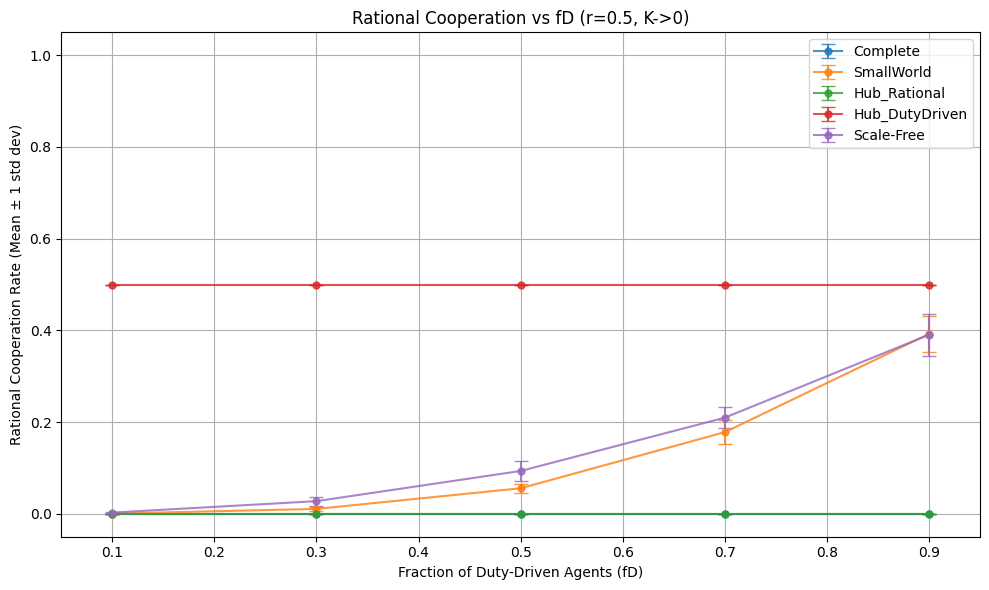

  Simulating r=1.0...


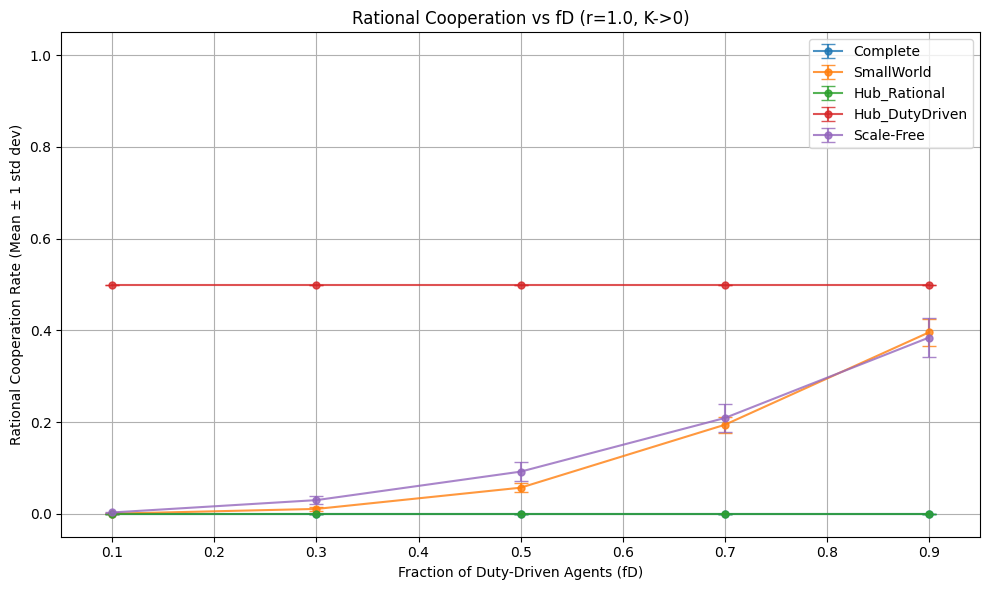

  Simulating r=1.5...


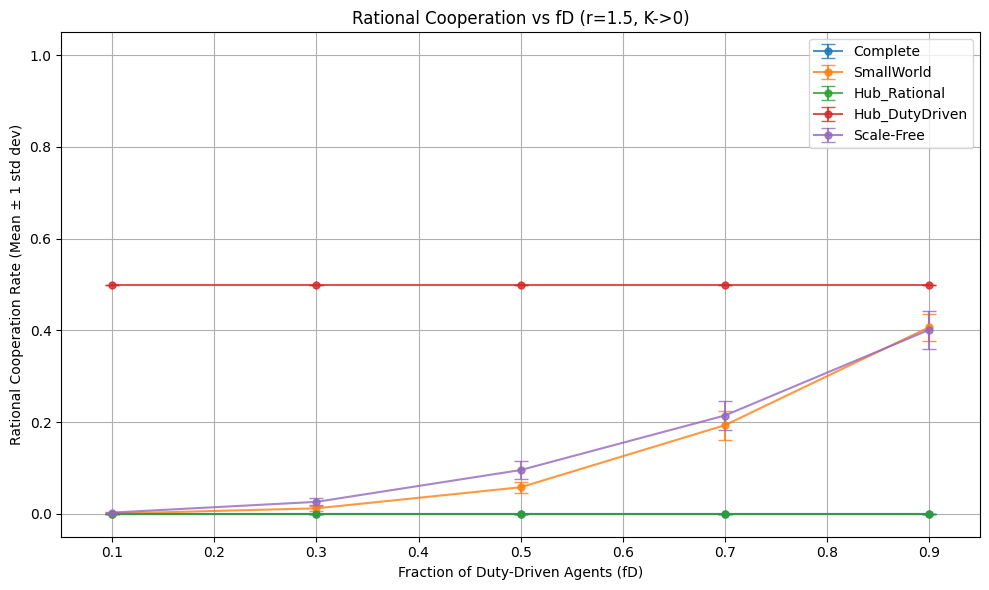

  Simulating r=2.0...


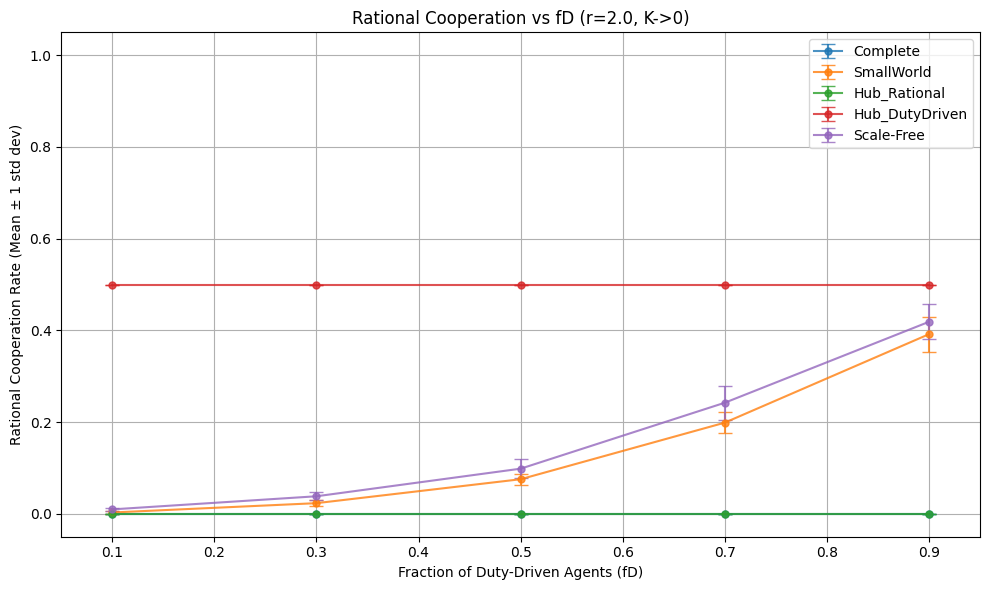

  Simulating r=2.5...


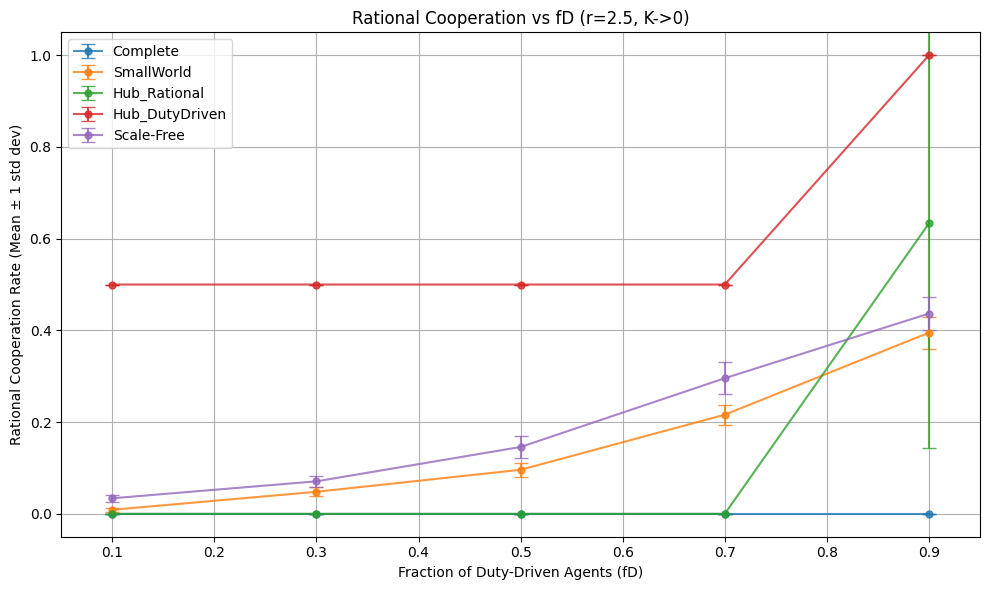


Running simulations for Figure 2 (Hysteresis) at r=1.5...
  Simulating fD=0.1...


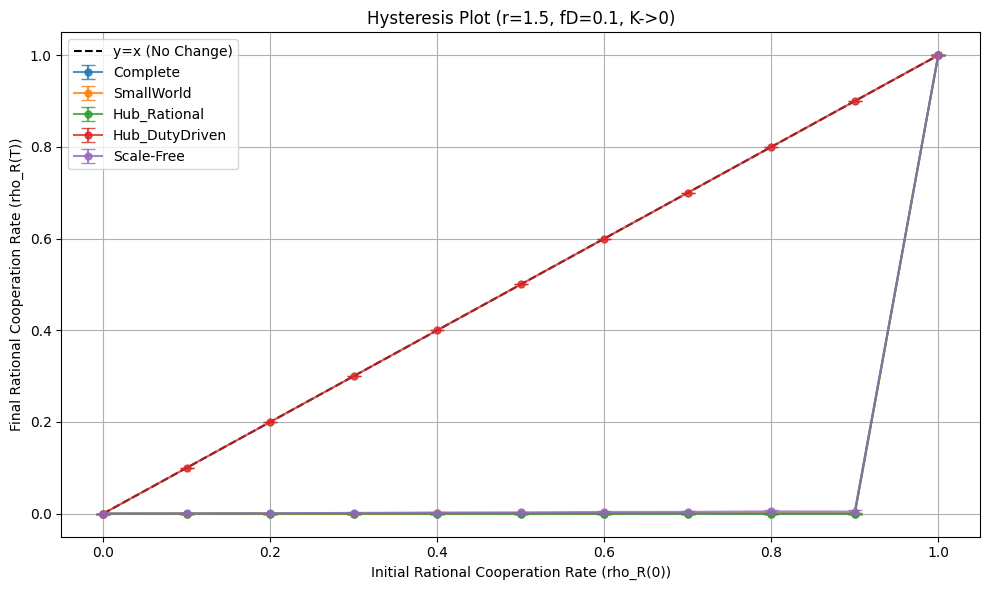

  Simulating fD=0.3...


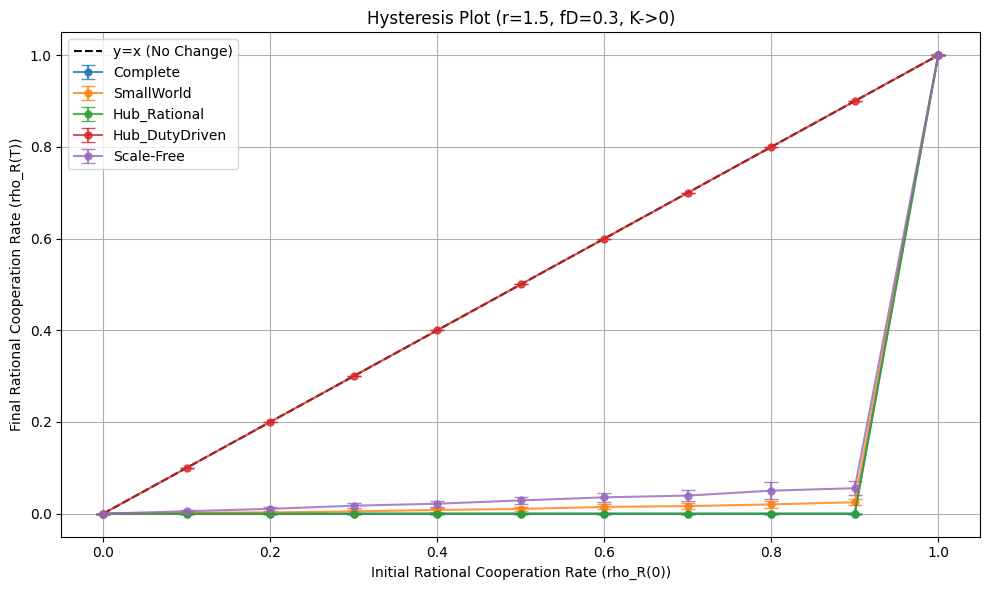

  Simulating fD=0.5...


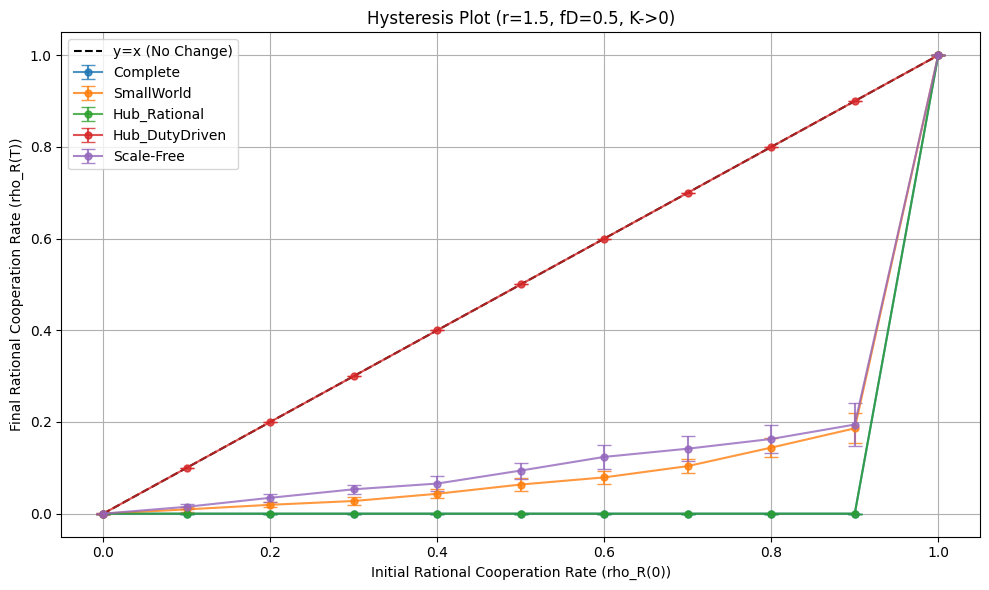

  Simulating fD=0.7...


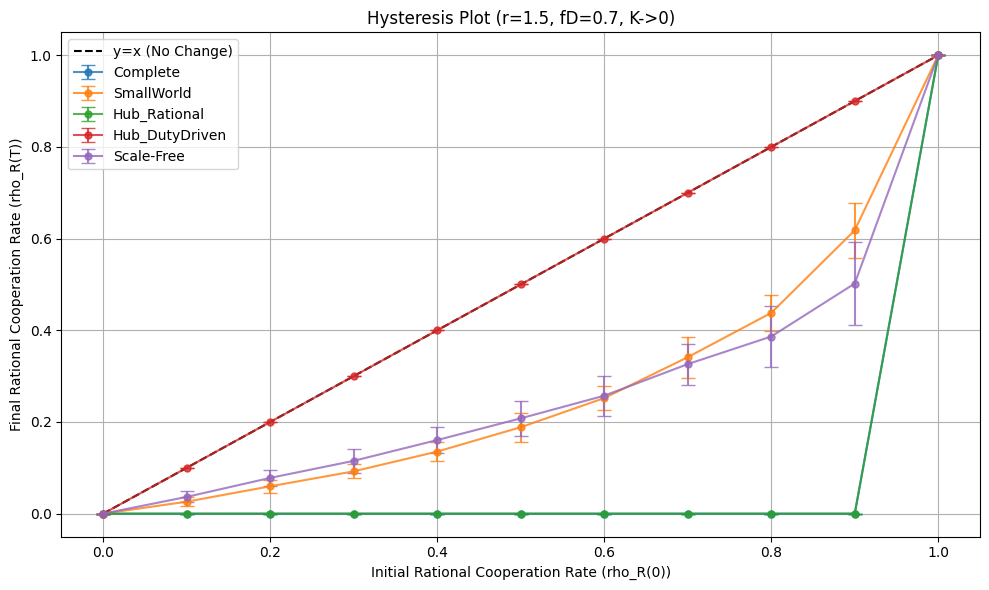

  Simulating fD=0.9...


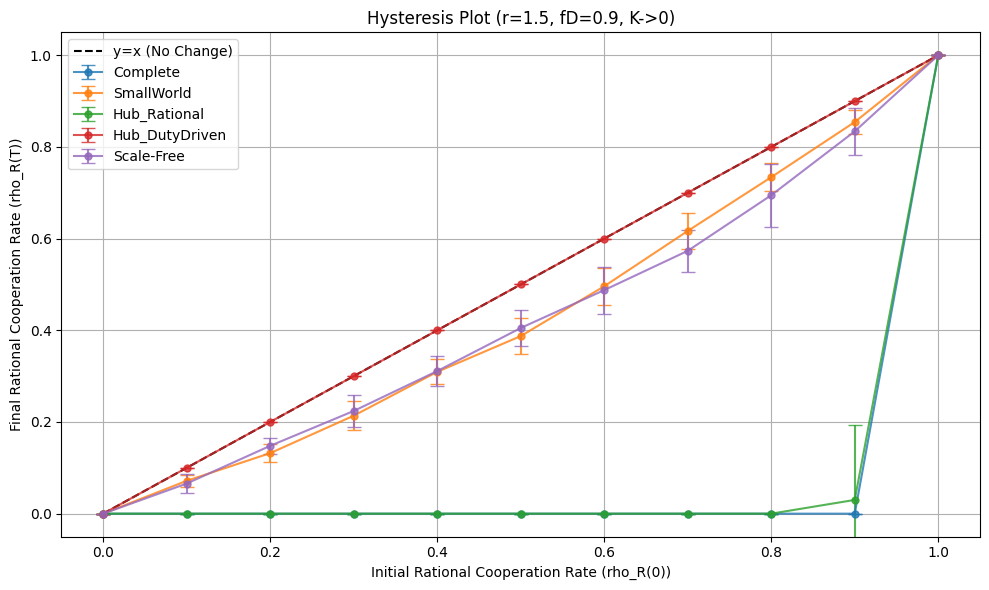

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------
# PARAMETERS (from Model Setup)
# ----------------------
N = 1000                # number of agents
c = 1                   # contribution cost
avg_degree = 4          # Average degree for SmallWorld/Scale-Free
timesteps = 200         # Number of timesteps
# K (Selection Intensity) is REMOVED, as we are in the K->0 limit

# Parameters for Figure 1 plots
fD_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9]) # Fraction of Duty-Driven
r_values = np.arange(0.5, 2.6, 0.5)  # Synergy factor
rho_R_0_fig1 = 0.5           # Fixed Initial Rational Cooperation Rate

# Parameters for Figure 2 (Hysteresis) plots
rho_R_0_values_fig2 = np.arange(0.0, 1.1, 0.1) # X-axis for hysteresis
r_fig2 = 1.5 # Fixed synergy factor (as in PDF)
fD_values_fig2 = np.array([0.1, 0.3, 0.5, 0.7, 0.9]) # One plot per fD

mc_runs = 30            # Monte Carlo runs
topologies = ['Complete', 'SmallWorld', 'Hub_Rational', 'Hub_DutyDriven', 'Scale-Free']

# ----------------------
# HELPER FUNCTIONS
# ----------------------
def initialize_agents(N, fD, topo, initial_rational_coop):
    """
    Correctly initializes agent types and strategies,
    handling the hub-network ambiguity.
    """
    num_duty = int(fD * N)
    agents = np.zeros(N, dtype=np.int8)  # 0 = Rational, 1 = Duty-Driven

    # Assign Duty-Driven agents
    if topo == "Hub_DutyDriven":
        agents[0] = 1  # Hub
        remaining_duty = max(0, num_duty - 1)
        if remaining_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, remaining_duty, replace=False)] = 1
    elif topo == "Hub_Rational":
        agents[0] = 0  # Hub rational
        if num_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, num_duty, replace=False)] = 1
    else:
        if num_duty > 0:
            agents[np.random.choice(N, num_duty, replace=False)] = 1

    # Initialize strategies
    strategies = np.zeros(N, dtype=np.int8)  # All defect initially
    rational_idx = np.where(agents == 0)[0]
    num_rational_coop = int(len(rational_idx) * initial_rational_coop)
    if num_rational_coop > 0:
        coop_idx = np.random.choice(rational_idx, num_rational_coop, replace=False)
        strategies[coop_idx] = 1

    # All Duty-Driven agents cooperate
    strategies[agents == 1] = 1
    return agents, strategies

def compute_payoff(A, strategies, r, topo, N, c):
    """
    Computes payoffs based on the PDF's equations.
    """
    if topo == "Complete":
        total = np.sum(strategies)
        payoffs = r * total / N - strategies * c
    else:
        C = A.dot(strategies) + strategies
        degree = np.asarray(A.sum(axis=1)).flatten()
        payoffs = r * C / (degree + 1 + 1e-9) - strategies * c
    return payoffs

def deterministic_update(A, strategies, agents, pi, topo, N):
    """
    CORRECTED UPDATE RULE: Deterministic "Copy-if-Better" (K->0 limit)
    """
    rational_idx = np.where(agents == 0)[0]
    num_rational = len(rational_idx)
    if num_rational == 0:
        return strategies

    # --- Role model selection (j) ---
    if topo == "Complete":
        j = np.random.randint(0, N, num_rational)
        self_pick = (j == rational_idx)
        while np.any(self_pick):
            j[self_pick] = np.random.randint(0, N, np.sum(self_pick))
            self_pick = (j == rational_idx)

    else:
        # Vectorized role model selection for sparse graphs
        starts = A.indptr[rational_idx]
        ends = A.indptr[rational_idx + 1]
        neighbor_counts = ends - starts

        j = rational_idx.copy()
        has_neighbors_mask = (neighbor_counts > 0)
        num_with_neighbors = np.sum(has_neighbors_mask)

        if num_with_neighbors > 0:
            rational_with_neighbors_starts = starts[has_neighbors_mask]
            neighbor_counts_with = neighbor_counts[has_neighbors_mask]
            random_offsets = (np.random.rand(num_with_neighbors) * neighbor_counts_with).astype(int)
            j_indices = rational_with_neighbors_starts + random_offsets
            chosen_neighbors = A.indices[j_indices]
            j[has_neighbors_mask] = chosen_neighbors

    # --- Strategy adoption (DETERMINISTIC) ---
    pi_j = pi[j]
    pi_i = pi[rational_idx]

    # Agent i adopts j's strategy if and only if pi_j > pi_i
    adopt = (pi_j > pi_i)

    strategies[rational_idx[adopt]] = strategies[j[adopt]]
    return strategies

def generate_network(topo, N, avg_degree):
    """
    Generates the network graph G and returns its sparse adjacency matrix A.
    """
    if topo == "Complete":
        return None
    elif topo == "SmallWorld":
        G = nx.watts_strogatz_graph(N, avg_degree, 0.3)
    elif topo in ["Hub_Rational", "Hub_DutyDriven"]:
        G = nx.star_graph(N-1)
    elif topo == "Scale-Free":
        m = max(1, avg_degree // 2)
        G = nx.barabasi_albert_graph(N, m)
    return nx.to_scipy_sparse_array(G, format='csr')

def simulate_vectorized(fD, r, timesteps, topo, N, c, avg_degree, initial_rational_coop):
    """
    Main simulation loop (K parameter removed).
    """
    A = generate_network(topo, N, avg_degree)
    agents, strategies = initialize_agents(N, fD, topo, initial_rational_coop)

    for _ in range(timesteps):
        pi = compute_payoff(A, strategies, r, topo, N, c)
        # Call the new deterministic update function
        strategies = deterministic_update(A, strategies, agents, pi, topo, N)

    rational_idx = np.where(agents == 0)[0]
    return np.mean(strategies[rational_idx]) if len(rational_idx) > 0 else np.nan

# ----------------------
# RUN SIMULATIONS
# ----------------------

def run_figure_1_simulations():
    """
    Generates the plots for Rational Cooperation vs. fD
    (like in Figure 1 of the PDF)
    """
    print("Running simulations for Figure 1 (rho_R vs. fD)...")
    for r in r_values:
        results_mean = {topo: [] for topo in topologies}
        results_std = {topo: [] for topo in topologies}
        print(f"  Simulating r={r}...")

        for fD in fD_values:
            for topo in topologies:
                mc_coop_rates = []
                for _ in range(mc_runs):
                    coop = simulate_vectorized(fD, r, timesteps, topo, N, c, avg_degree,
                                             initial_rational_coop=rho_R_0_fig1)
                    mc_coop_rates.append(coop)

                mean_coop = np.nanmean(mc_coop_rates)
                std_coop = np.nanstd(mc_coop_rates, ddof=1)
                results_mean[topo].append(mean_coop)
                results_std[topo].append(std_coop)

        # PLOT
        plt.figure(figsize=(10,6))
        for topo in topologies:
            plt.errorbar(fD_values, results_mean[topo], yerr=results_std[topo],
                         label=topo, marker='o', markersize=5, capsize=5, alpha=0.8)
        plt.xlabel("Fraction of Duty-Driven Agents (fD)")
        plt.ylabel("Rational Cooperation Rate (Mean ± 1 std dev)")
        plt.title(f"Rational Cooperation vs fD (r={r}, K->0)")
        plt.ylim(-0.05, 1.05)
        plt.xlim(min(fD_values) - 0.05, max(fD_values) + 0.05)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"Fig1_DETERMINISTIC_r_{r}.png")
        plt.show()

def run_figure_2_simulations():
    """
    Generates the Hysteresis plots for Final vs. Initial Cooperation
    (like in Figure 2 of the PDF)
    """
    print(f"\nRunning simulations for Figure 2 (Hysteresis) at r={r_fig2}...")

    for fD in fD_values_fig2:
        print(f"  Simulating fD={fD}...")
        results_mean = {topo: [] for topo in topologies}
        results_std = {topo: [] for topo in topologies}

        for rho_R_0 in rho_R_0_values_fig2:
            for topo in topologies:
                mc_coop_rates = []
                for _ in range(mc_runs):
                    coop = simulate_vectorized(fD, r_fig2, timesteps, topo, N, c, avg_degree,
                                             initial_rational_coop=rho_R_0)
                    mc_coop_rates.append(coop)

                mean_coop = np.nanmean(mc_coop_rates)
                std_coop = np.nanstd(mc_coop_rates, ddof=1)
                results_mean[topo].append(mean_coop)
                results_std[topo].append(std_coop)

        # PLOT
        plt.figure(figsize=(10,6))

        # Plot the "y=x" (No Change) line for reference
        plt.plot([0, 1], [0, 1], 'k--', label='y=x (No Change)')

        for topo in topologies:
            plt.errorbar(rho_R_0_values_fig2, results_mean[topo], yerr=results_std[topo],
                         label=topo, marker='o', markersize=5, capsize=5, alpha=0.8)

        plt.xlabel("Initial Rational Cooperation Rate (rho_R(0))")
        plt.ylabel("Final Rational Cooperation Rate (rho_R(T))")
        plt.title(f"Hysteresis Plot (r={r_fig2}, fD={fD}, K->0)")
        plt.ylim(-0.05, 1.05)
        plt.xlim(-0.05, 1.05)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"Fig2_Hysteresis_fD_{fD}.png")
        plt.show()

if __name__ == "__main__":
    run_figure_1_simulations()
    run_figure_2_simulations()

In [4]:
import zipfile
import os

image_files = [f for f in os.listdir('.') if f.endswith('.png')]

with zipfile.ZipFile('generated_plots.zip', 'w') as zipf:
    for image in image_files:
        zipf.write(image)

Running simulations for Chapter 5 (Targeted Seeding)...
  Simulating r=0.5...


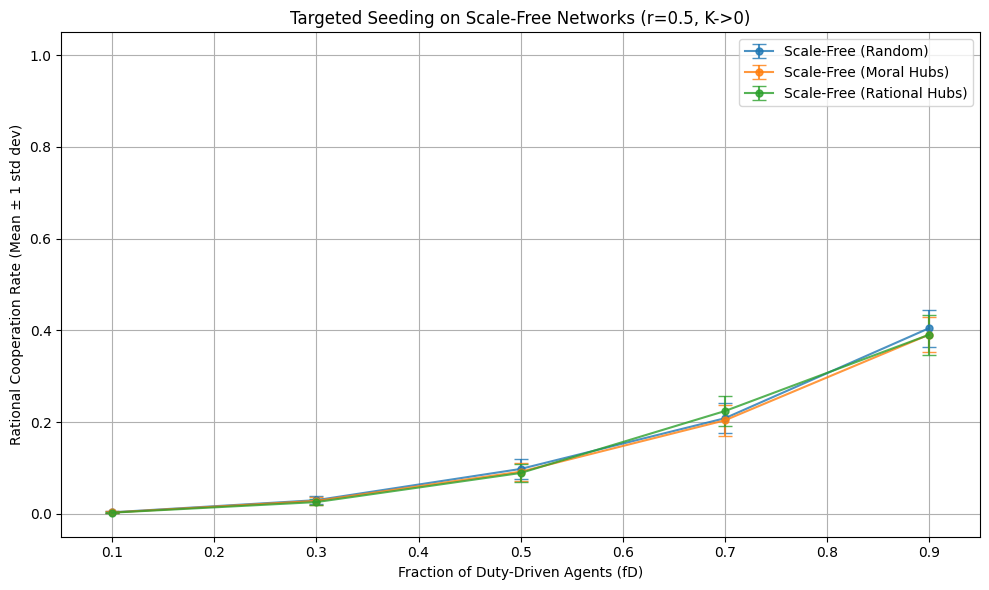

  Simulating r=1.0...


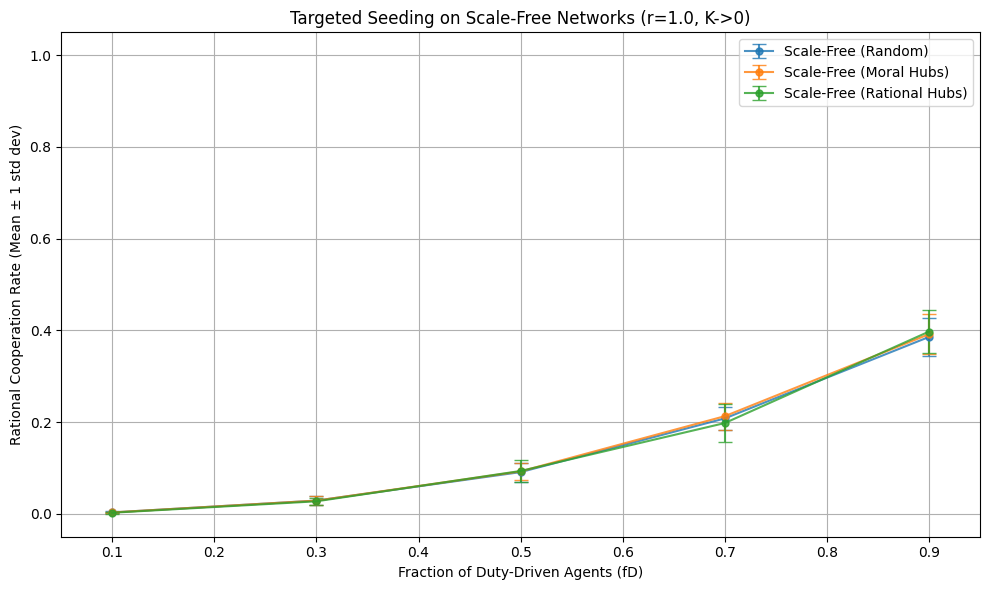

  Simulating r=1.5...


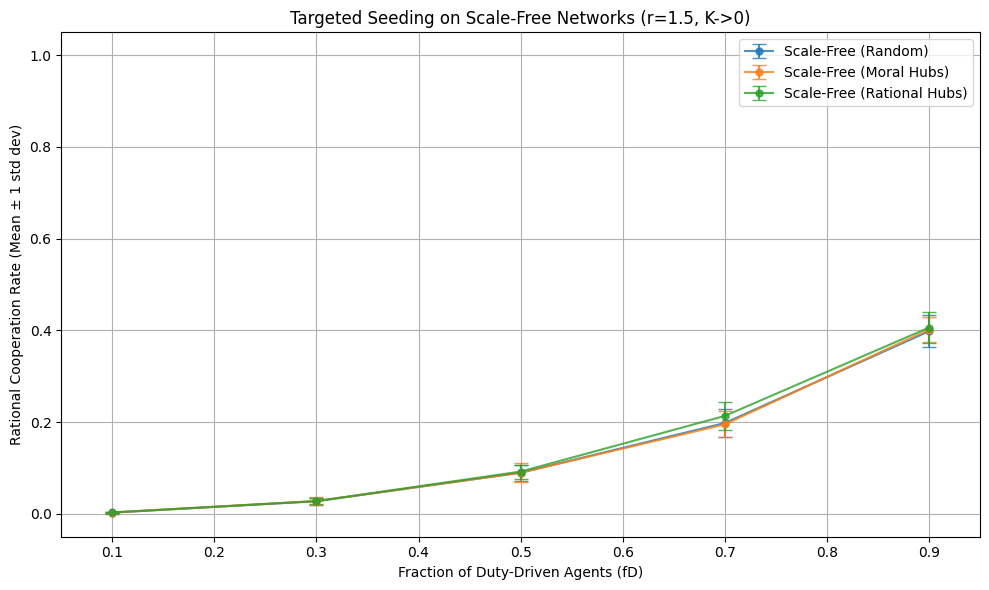

  Simulating r=2.0...


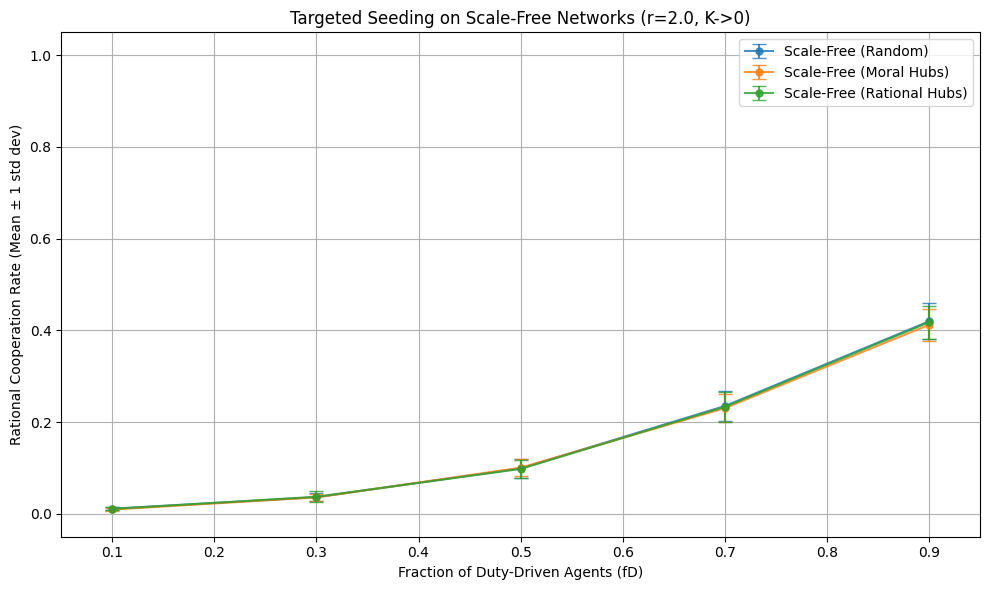

  Simulating r=2.5...


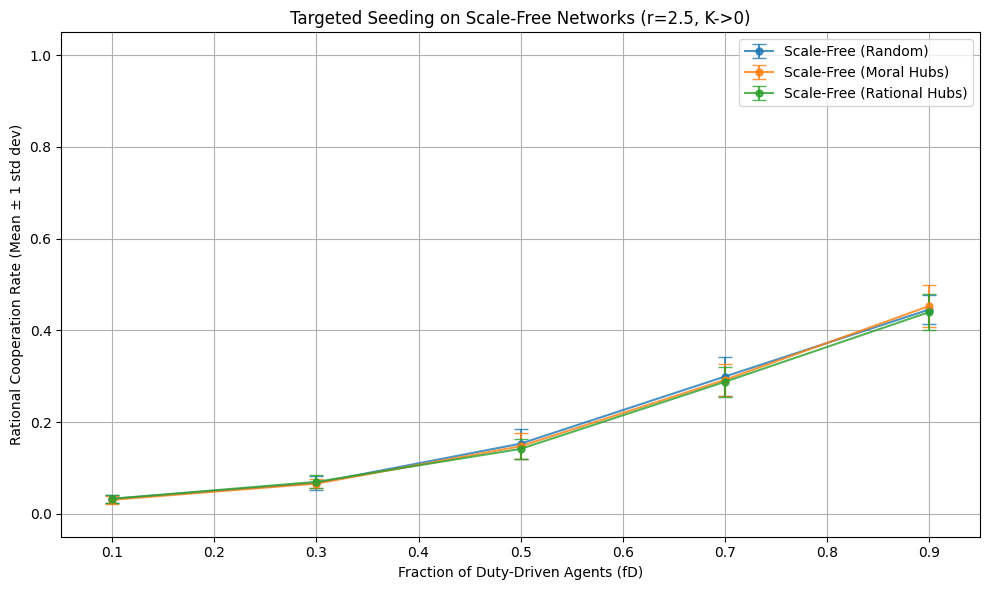

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import csr_array

# ----------------------
# PARAMETERS
# ----------------------
N = 1000                # number of agents
c = 1                   # contribution cost
avg_degree = 4          # Average degree for Scale-Free
timesteps = 200         # Number of timesteps
mc_runs = 30            # Monte Carlo runs
rho_R_0 = 0.5           # Initial Rational Cooperation Rate
hub_percent = 0.1       # Top 10% of nodes are 'hubs'

# Simulation parameters
fD_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9]) # Fraction of Duty-Driven
r_values = np.arange(0.5, 2.6, 0.5)  # Synergy factor

# Define the three scenarios for Chapter 5
seeding_strategies = ['Scale-Free (Random)', 'Scale-Free (Moral Hubs)', 'Scale-Free (Rational Hubs)']

# ----------------------
# HELPER FUNCTIONS
# ----------------------

def initialize_agents(N, fD, G, topo, initial_rational_coop,
                      seeding_strategy='random', hub_percent=0.1):
    """
    Initializes agent types and strategies with targeted seeding logic.
    """
    num_duty = int(fD * N)
    agents = np.zeros(N, dtype=np.int8)  # 0 = Rational, 1 = Duty-Driven

    # --- 1. Assign Agent Types (A_R vs A_D) ---

    if topo == "Hub_DutyDriven":
        agents[0] = 1
        remaining_duty = max(0, num_duty - 1)
        if remaining_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, remaining_duty, replace=False)] = 1

    elif topo == "Hub_Rational":
        agents[0] = 0
        if num_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, num_duty, replace=False)] = 1

    elif topo == "Scale-Free":
        # This is the new logic for Chapter 5
        degrees = dict(G.degree())
        sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)

        num_hubs = int(N * hub_percent)
        hub_nodes = np.array(sorted_nodes[:num_hubs])
        non_hub_nodes = np.array(sorted_nodes[num_hubs:])

        if seeding_strategy == 'Scale-Free (Moral Hubs)':
            # Prioritize placing A_D agents on hubs
            num_hubs_to_seed = min(num_duty, len(hub_nodes))
            duty_hubs = np.random.choice(hub_nodes, num_hubs_to_seed, replace=False)
            agents[duty_hubs] = 1

            num_duty_remaining = num_duty - num_hubs_to_seed
            if num_duty_remaining > 0:
                # If budget > hubs, place the rest on non-hubs
                agents[np.random.choice(non_hub_nodes, num_duty_remaining, replace=False)] = 1

        elif seeding_strategy == 'Scale-Free (Rational Hubs)':
            # Force hubs to be Rational (agents[hub_nodes] = 0)
            # Place A_D agents *only* on non-hubs
            num_duty_to_place = min(num_duty, len(non_hub_nodes))
            if num_duty_to_place > 0:
                agents[np.random.choice(non_hub_nodes, num_duty_to_place, replace=False)] = 1

        else: # 'Scale-Free (Random)'
            if num_duty > 0:
                agents[np.random.choice(N, num_duty, replace=False)] = 1

    else: # Complete or SmallWorld (use random seeding)
        if num_duty > 0:
            agents[np.random.choice(N, num_duty, replace=False)] = 1

    # --- 2. Initialize Strategies ---
    strategies = np.zeros(N, dtype=np.int8)
    rational_idx = np.where(agents == 0)[0]
    num_rational_coop = int(len(rational_idx) * initial_rational_coop)

    if num_rational_coop > 0:
        coop_idx = np.random.choice(rational_idx, num_rational_coop, replace=False)
        strategies[coop_idx] = 1

    strategies[agents == 1] = 1
    return agents, strategies

def generate_network(topo, N, avg_degree):
    """
    Generates the network graph G (NetworkX object).
    """
    if topo == "Complete":
        return None # Special case
    elif topo == "SmallWorld":
        G = nx.watts_strogatz_graph(N, avg_degree, 0.3)
    elif topo in ["Hub_Rational", "Hub_DutyDriven"]:
        G = nx.star_graph(N-1)
    elif topo == "Scale-Free":
        m = max(1, avg_degree // 2)
        G = nx.barabasi_albert_graph(N, m)
    else:
        raise ValueError(f"Unknown topology: {topo}")

    return G

def compute_payoff(A, strategies, r, topo, N, c):
    """
    Computes payoffs based on the PDF's equations.
    """
    if topo == "Complete":
        total = np.sum(strategies)
        payoffs = r * total / N - strategies * c
    else:
        C = A.dot(strategies) + strategies
        degree = np.asarray(A.sum(axis=1)).flatten()
        payoffs = r * C / (degree + 1 + 1e-9) - strategies * c
    return payoffs

def deterministic_update(A, strategies, agents, pi, topo, N):
    """
    Deterministic "Copy-if-Better" (K->0 limit) update rule.
    """
    rational_idx = np.where(agents == 0)[0]
    num_rational = len(rational_idx)
    if num_rational == 0:
        return strategies

    # --- Role model selection (j) ---
    if topo == "Complete":
        j = np.random.randint(0, N, num_rational)
        self_pick = (j == rational_idx)
        while np.any(self_pick):
            j[self_pick] = np.random.randint(0, N, np.sum(self_pick))
            self_pick = (j == rational_idx)
    else:
        starts = A.indptr[rational_idx]
        ends = A.indptr[rational_idx + 1]
        neighbor_counts = ends - starts
        j = rational_idx.copy()
        has_neighbors_mask = (neighbor_counts > 0)
        num_with_neighbors = np.sum(has_neighbors_mask)
        if num_with_neighbors > 0:
            rational_with_neighbors_starts = starts[has_neighbors_mask]
            neighbor_counts_with = neighbor_counts[has_neighbors_mask]
            random_offsets = (np.random.rand(num_with_neighbors) * neighbor_counts_with).astype(int)
            j_indices = rational_with_neighbors_starts + random_offsets
            chosen_neighbors = A.indices[j_indices]
            j[has_neighbors_mask] = chosen_neighbors

    # --- Strategy adoption (DETERMINISTIC) ---
    pi_j = pi[j]
    pi_i = pi[rational_idx]
    adopt = (pi_j > pi_i)
    strategies[rational_idx[adopt]] = strategies[j[adopt]]
    return strategies

def simulate_vectorized(fD, r, timesteps, topo, N, c, avg_degree,
                        initial_rational_coop, seeding_strategy='random'):
    """
    Main simulation loop.
    """
    # 1. Generate the NetworkX graph object
    G = generate_network(topo, N, avg_degree)

    # 2. Convert G to sparse matrix A (if not a Complete graph)
    if G is not None:
        A = nx.to_scipy_sparse_array(G, format='csr')
    else:
        A = None # Complete graph handled separately

    # 3. Initialize agents using the graph G for hub-finding
    agents, strategies = initialize_agents(N, fD, G, topo,
                                         initial_rational_coop,
                                         seeding_strategy)

    # 4. Run simulation
    for _ in range(timesteps):
        pi = compute_payoff(A, strategies, r, topo, N, c)
        strategies = deterministic_update(A, strategies, agents, pi, topo, N)

    rational_idx = np.where(agents == 0)[0]
    return np.mean(strategies[rational_idx]) if len(rational_idx) > 0 else np.nan

# ----------------------
# RUN SIMULATION (for Chapter 5)
# ----------------------
def main_chapter5():
    """
    Generates the plots for Chapter 5: Targeted Seeding on Scale-Free Networks
    """
    print("Running simulations for Chapter 5 (Targeted Seeding)...")

    # Map friendly names to (topo, seeding_strategy) tuples
    topo_map = {
        'Scale-Free (Random)': ('Scale-Free', 'random'),
        'Scale-Free (Moral Hubs)': ('Scale-Free', 'moral_hubs'),
        'Scale-Free (Rational Hubs)': ('Scale-Free', 'rational_hubs')
    }

    for r in r_values:
        results_mean = {name: [] for name in topo_map}
        results_std = {name: [] for name in topo_map}
        print(f"  Simulating r={r}...")

        for fD in fD_values:
            for name, (topo, seed_strat) in topo_map.items():
                mc_coop_rates = []
                for _ in range(mc_runs):
                    coop = simulate_vectorized(fD, r, timesteps, topo, N, c,
                                             avg_degree, rho_R_0,
                                             seeding_strategy=seed_strat)
                    mc_coop_rates.append(coop)

                mean_coop = np.nanmean(mc_coop_rates)
                std_coop = np.nanstd(mc_coop_rates, ddof=1)
                results_mean[name].append(mean_coop)
                results_std[name].append(std_coop)

        # PLOT
        plt.figure(figsize=(10,6))
        for name in topo_map:
            plt.errorbar(fD_values, results_mean[name], yerr=results_std[name],
                         label=name, marker='o', markersize=5, capsize=5, alpha=0.8)

        plt.xlabel("Fraction of Duty-Driven Agents (fD)")
        plt.ylabel("Rational Cooperation Rate (Mean ± 1 std dev)")
        plt.title(f"Targeted Seeding on Scale-Free Networks (r={r}, K->0)")
        plt.ylim(-0.05, 1.05)
        plt.xlim(min(fD_values) - 0.05, max(fD_values) + 0.05)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"Fig5_TargetedSeeding_r_{r}.png")
        plt.show()

if __name__ == "__main__":
    main_chapter5()


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import csr_array

# ----------------------
# PARAMETERS
# ----------------------
N = 1000                # number of agents
c = 1                   # contribution cost
avg_degree = 4          # Average degree for Scale-Free
timesteps = 200         # Number of timesteps
mc_runs = 30            # Monte Carlo runs
rho_R_0 = 0.5           # Initial Rational Cooperation Rate
hub_percent = 0.1       # Top 10% of nodes are 'hubs'

# Simulation parameters
fD_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9]) # Fraction of Duty-Driven
r_values = np.arange(0.5, 2.6, 0.5)  # Synergy factor

# Define the three scenarios for Chapter 5
seeding_strategies = ['Scale-Free (Random)', 'Scale-Free (Moral Hubs)', 'Scale-Free (Rational Hubs)']

# ----------------------
# HELPER FUNCTIONS
# ----------------------

def initialize_agents(N, fD, G, topo, initial_rational_coop,
                      seeding_strategy='random', hub_percent=0.1):
    """
    Initializes agent types and strategies with targeted seeding logic.
    """
    num_duty = int(fD * N)
    agents = np.zeros(N, dtype=np.int8)  # 0 = Rational, 1 = Duty-Driven

    # --- 1. Assign Agent Types (A_R vs A_D) ---

    if topo == "Hub_DutyDriven":
        agents[0] = 1
        remaining_duty = max(0, num_duty - 1)
        if remaining_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, remaining_duty, replace=False)] = 1

    elif topo == "Hub_Rational":
        agents[0] = 0
        if num_duty > 0:
            leaf_idx = np.arange(1, N)
            agents[np.random.choice(leaf_idx, num_duty, replace=False)] = 1

    elif topo == "Scale-Free":
        # This is the new logic for Chapter 5
        degrees = dict(G.degree())
        sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)

        num_hubs = int(N * hub_percent)
        hub_nodes = np.array(sorted_nodes[:num_hubs])
        non_hub_nodes = np.array(sorted_nodes[num_hubs:])

        if seeding_strategy == 'Scale-Free (Moral Hubs)':
            # Prioritize placing A_D agents on hubs
            num_hubs_to_seed = min(num_duty, len(hub_nodes))
            duty_hubs = np.random.choice(hub_nodes, num_hubs_to_seed, replace=False)
            agents[duty_hubs] = 1

            num_duty_remaining = num_duty - num_hubs_to_seed
            if num_duty_remaining > 0:
                # If budget > hubs, place the rest on non-hubs
                agents[np.random.choice(non_hub_nodes, num_duty_remaining, replace=False)] = 1

        elif seeding_strategy == 'Scale-Free (Rational Hubs)':
            # Force hubs to be Rational (agents[hub_nodes] = 0)
            # Place A_D agents *only* on non-hubs
            num_duty_to_place = min(num_duty, len(non_hub_nodes))
            if num_duty_to_place > 0:
                agents[np.random.choice(non_hub_nodes, num_duty_to_place, replace=False)] = 1

        else: # 'Scale-Free (Random)'
            if num_duty > 0:
                agents[np.random.choice(N, num_duty, replace=False)] = 1

    else: # Complete or SmallWorld (use random seeding)
        if num_duty > 0:
            agents[np.random.choice(N, num_duty, replace=False)] = 1

    # --- 2. Initialize Strategies ---
    strategies = np.zeros(N, dtype=np.int8)
    rational_idx = np.where(agents == 0)[0]
    num_rational_coop = int(len(rational_idx) * initial_rational_coop)

    if num_rational_coop > 0:
        coop_idx = np.random.choice(rational_idx, num_rational_coop, replace=False)
        strategies[coop_idx] = 1

    strategies[agents == 1] = 1
    return agents, strategies

def generate_network(topo, N, avg_degree):
    """
    Generates the network graph G (NetworkX object).
    """
    if topo == "Complete":
        return None # Special case
    elif topo == "SmallWorld":
        G = nx.watts_strogatz_graph(N, avg_degree, 0.3)
    elif topo in ["Hub_Rational", "Hub_DutyDriven"]:
        G = nx.star_graph(N-1)
    elif topo == "Scale-Free":
        m = max(1, avg_degree // 2)
        G = nx.barabasi_albert_graph(N, m)
    else:
        raise ValueError(f"Unknown topology: {topo}")

    return G

def compute_payoff(A, strategies, r, topo, N, c):
    """
    Computes payoffs based on the PDF's equations.
    """
    if topo == "Complete":
        total = np.sum(strategies)
        payoffs = r * total / N - strategies * c
    else:
        C = A.dot(strategies) + strategies
        degree = np.asarray(A.sum(axis=1)).flatten()
        payoffs = r * C / (degree + 1 + 1e-9) - strategies * c
    return payoffs

def deterministic_update(A, strategies, agents, pi, topo, N):
    """
    Deterministic "Copy-if-Better" (K->0 limit) update rule.
    """
    rational_idx = np.where(agents == 0)[0]
    num_rational = len(rational_idx)
    if num_rational == 0:
        return strategies

    # --- Role model selection (j) ---
    if topo == "Complete":
        j = np.random.randint(0, N, num_rational)
        self_pick = (j == rational_idx)
        while np.any(self_pick):
            j[self_pick] = np.random.randint(0, N, np.sum(self_pick))
            self_pick = (j == rational_idx)
    else:
        starts = A.indptr[rational_idx]
        ends = A.indptr[rational_idx + 1]
        neighbor_counts = ends - starts
        j = rational_idx.copy()
        has_neighbors_mask = (neighbor_counts > 0)
        num_with_neighbors = np.sum(has_neighbors_mask)
        if num_with_neighbors > 0:
            rational_with_neighbors_starts = starts[has_neighbors_mask]
            neighbor_counts_with = neighbor_counts[has_neighbors_mask]
            random_offsets = (np.random.rand(num_with_neighbors) * neighbor_counts_with).astype(int)
            j_indices = rational_with_neighbors_starts + random_offsets
            chosen_neighbors = A.indices[j_indices]
            j[has_neighbors_mask] = chosen_neighbors

    # --- Strategy adoption (DETERMINISTIC) ---
    pi_j = pi[j]
    pi_i = pi[rational_idx]
    adopt = (pi_j > pi_i)
    strategies[rational_idx[adopt]] = strategies[j[adopt]]
    return strategies

def simulate_vectorized(fD, r, timesteps, topo, N, c, avg_degree,
                        initial_rational_coop, seeding_strategy='random'):
    """
    Main simulation loop.
    """
    # 1. Generate the NetworkX graph object
    G = generate_network(topo, N, avg_degree)

    # 2. Convert G to sparse matrix A (if not a Complete graph)
    if G is not None:
        A = nx.to_scipy_sparse_array(G, format='csr')
    else:
        A = None # Complete graph handled separately

    # 3. Initialize agents using the graph G for hub-finding
    agents, strategies = initialize_agents(N, fD, G, topo,
                                         initial_rational_coop,
                                         seeding_strategy)

    # 4. Run simulation
    for _ in range(timesteps):
        pi = compute_payoff(A, strategies, r, topo, N, c)
        strategies = deterministic_update(A, strategies, agents, pi, topo, N)

    rational_idx = np.where(agents == 0)[0]
    return np.mean(strategies[rational_idx]) if len(rational_idx) > 0 else np.nan

# ----------------------
# RUN SIMULATION (for Chapter 5)
# ----------------------
def main_chapter5():
    """
    Generates the plots for Chapter 5: Targeted Seeding on Scale-Free Networks
    """
    print("Running simulations for Chapter 5 (Targeted Seeding)...")

    # Map friendly names to (topo, seeding_strategy) tuples
    topo_map = {
        'Scale-Free (Random)': ('Scale-Free', 'random'),
        'Scale-Free (Moral Hubs)': ('Scale-Free', 'moral_hubs'),
        'Scale-Free (Rational Hubs)': ('Scale-Free', 'rational_hubs')
    }

    for r in r_values:
        results_mean = {name: [] for name in topo_map}
        results_std = {name: [] for name in topo_map}
        print(f"  Simulating r={r}...")

        for fD in fD_values:
            for name, (topo, seed_strat) in topo_map.items():
                mc_coop_rates = []
                for _ in range(mc_runs):
                    coop = simulate_vectorized(fD, r, timesteps, topo, N, c,
                                             avg_degree, rho_R_0,
                                             seeding_strategy=seed_strat)
                    mc_coop_rates.append(coop)

                mean_coop = np.nanmean(mc_coop_rates)
                std_coop = np.nanstd(mc_coop_rates, ddof=1)
                results_mean[name].append(mean_coop)
                results_std[name].append(std_coop)

        # PLOT
        plt.figure(figsize=(10,6))
        for name in topo_map:
            plt.errorbar(fD_values, results_mean[name], yerr=results_std[name],
                         label=name, marker='o', markersize=5, capsize=5, alpha=0.8)

        plt.xlabel("Fraction of Duty-Driven Agents (fD)")
        plt.ylabel("Rational Cooperation Rate (Mean ± 1 std dev)")
        plt.title(f"Targeted Seeding on Scale-Free Networks (r={r}, K->0)")
        plt.ylim(-0.05, 1.05)
        plt.xlim(min(fD_values) - 0.05, max(fD_values) + 0.05)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"Fig5_TargetedSeeding_r_{r}.png")
        plt.show()

if __name__ == "__main__":
    main_chapter5()


Running simulations for Chapter 5 (Targeted Seeding)...
  Simulating r=0.5...


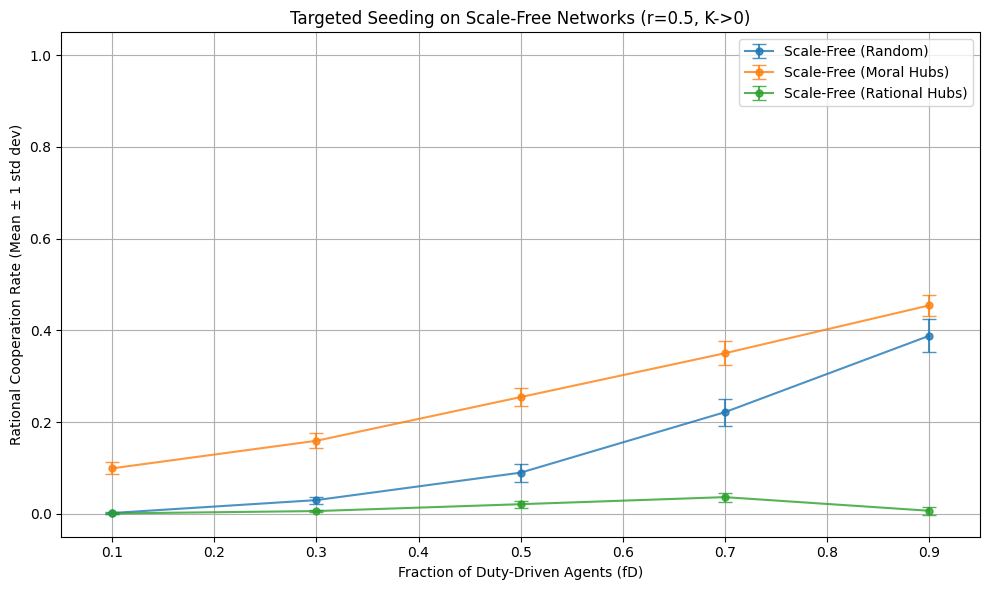

  Simulating r=1.0...


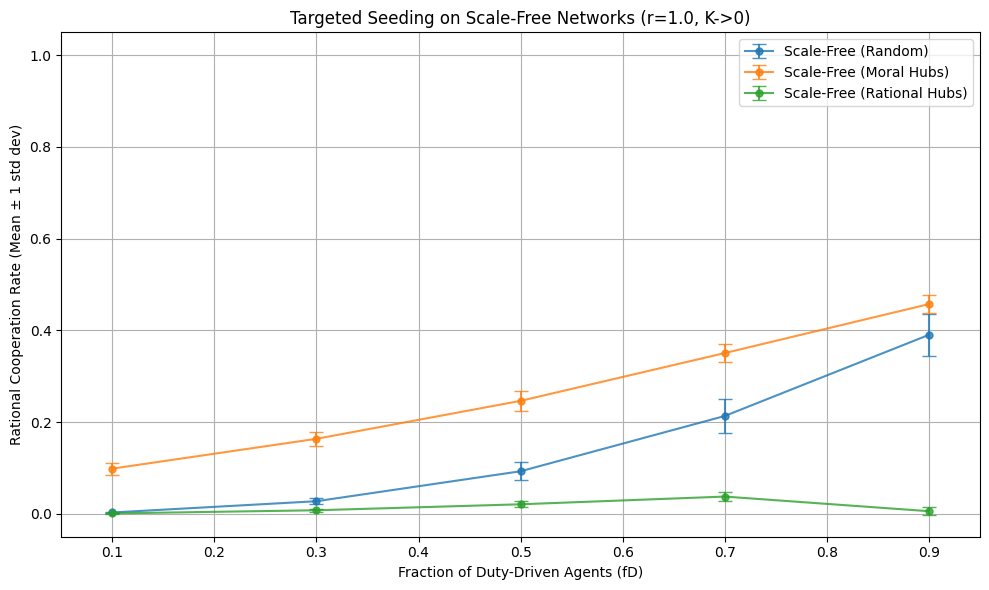

  Simulating r=1.5...


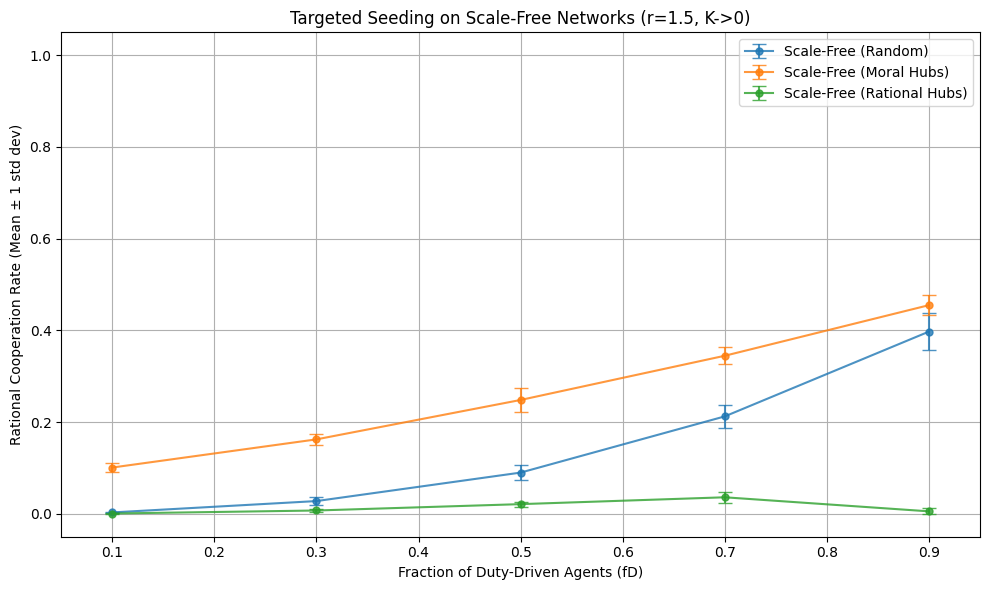

  Simulating r=2.0...


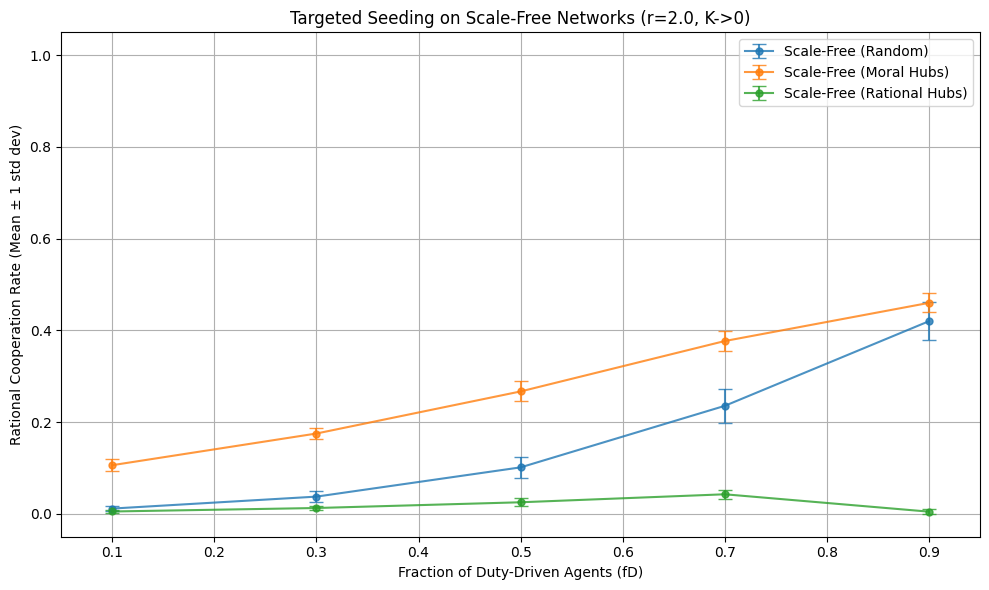

  Simulating r=2.5...


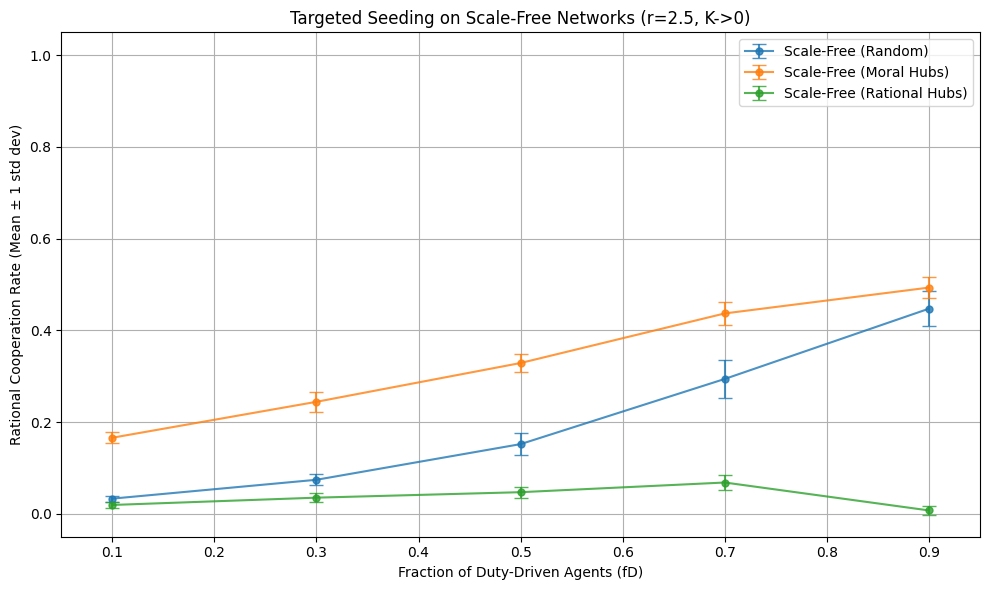

In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import csr_array

# ----------------------
# PARAMETERS
# ----------------------
N = 1000                # number of agents
c = 1                   # contribution cost
avg_degree = 4          # Average degree for Scale-Free (m=2)
timesteps = 200         # Number of timesteps
mc_runs = 30            # Monte Carlo runs
rho_R_0 = 0.5           # Initial Rational Cooperation Rate
hub_percent = 0.1       # Top 10% of nodes are 'hubs'

# Simulation parameters
fD_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9]) # Fraction of Duty-Driven
r_values = np.arange(0.5, 2.6, 0.5)  # Synergy factor

# Define the three scenarios for Chapter 5
seeding_strategies = ['Scale-Free (Random)', 'Scale-Free (Moral Hubs)', 'Scale-Free (Rational Hubs)']

# ----------------------
# HELPER FUNCTIONS
# ----------------------

def initialize_agents(N, fD, G, initial_rational_coop,
                      seeding_strategy='random', hub_percent=0.1):
    """
    Initializes agent types and strategies with targeted seeding logic
    for Scale-Free networks.
    """
    num_duty = int(fD * N)
    agents = np.zeros(N, dtype=np.int8)  # 0 = Rational, 1 = Duty-Driven

    # --- 1. Assign Agent Types (A_R vs A_D) ---

    # This is the logic for Chapter 5
    degrees = dict(G.degree())
    sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)

    num_hubs = int(N * hub_percent)
    hub_nodes = np.array(sorted_nodes[:num_hubs])
    non_hub_nodes = np.array(sorted_nodes[num_hubs:])

    if seeding_strategy == 'Scale-Free (Moral Hubs)':
        # Prioritize placing A_D agents on hubs
        num_hubs_to_seed = min(num_duty, len(hub_nodes))
        duty_hubs = np.random.choice(hub_nodes, num_hubs_to_seed, replace=False)
        agents[duty_hubs] = 1

        num_duty_remaining = num_duty - num_hubs_to_seed
        if num_duty_remaining > 0:
            # If budget > hubs, place the rest on non-hubs
            agents[np.random.choice(non_hub_nodes, num_duty_remaining, replace=False)] = 1

    elif seeding_strategy == 'Scale-Free (Rational Hubs)':
        # Force hubs to be Rational (agents[hub_nodes] = 0)
        # Place A_D agents *only* on non-hubs
        num_duty_to_place = min(num_duty, len(non_hub_nodes))
        if num_duty_to_place > 0:
            agents[np.random.choice(non_hub_nodes, num_duty_to_place, replace=False)] = 1

    else: # 'Scale-Free (Random)'
        if num_duty > 0:
            agents[np.random.choice(N, num_duty, replace=False)] = 1

    # --- 2. Initialize Strategies ---
    strategies = np.zeros(N, dtype=np.int8)
    rational_idx = np.where(agents == 0)[0]
    num_rational_coop = int(len(rational_idx) * initial_rational_coop)

    if num_rational_coop > 0:
        coop_idx = np.random.choice(rational_idx, num_rational_coop, replace=False)
        strategies[coop_idx] = 1

    strategies[agents == 1] = 1
    return agents, strategies

def generate_network(N, avg_degree):
    """
    Generates the Scale-Free network graph G (NetworkX object).
    """
    m = max(1, avg_degree // 2)
    G = nx.barabasi_albert_graph(N, m)
    return G

def compute_payoff(A, strategies, r, N, c):
    """
    Computes payoffs for localized networks.
    """
    # C_i(t) = s_i(t) + sum(s_j(t) for j in N_i)
    C = A.dot(strategies) + strategies
    # k_i = |N_i|
    degree = np.asarray(A.sum(axis=1)).flatten()
    # pi_i(t) = r * (C_i / (k_i + 1)) - c * s_i
    payoffs = r * C / (degree + 1 + 1e-9) - strategies * c
    return payoffs

def deterministic_update(A, strategies, agents, pi, N):
    """
    Deterministic "Copy-if-Better" (K->0 limit) update rule.
    """
    rational_idx = np.where(agents == 0)[0]
    num_rational = len(rational_idx)
    if num_rational == 0:
        return strategies

    # --- Role model selection (j) ---
    starts = A.indptr[rational_idx]
    ends = A.indptr[rational_idx + 1]
    neighbor_counts = ends - starts

    # Start by assuming j=i (for k_i=0 agents)
    j = rational_idx.copy()

    # Find agents that *do* have neighbors
    has_neighbors_mask = (neighbor_counts > 0)
    num_with_neighbors = np.sum(has_neighbors_mask)

    if num_with_neighbors > 0:
        rational_with_neighbors_starts = starts[has_neighbors_mask]
        neighbor_counts_with = neighbor_counts[has_neighbors_mask]
        random_offsets = (np.random.rand(num_with_neighbors) * neighbor_counts_with).astype(int)
        j_indices = rational_with_neighbors_starts + random_offsets
        chosen_neighbors = A.indices[j_indices]
        j[has_neighbors_mask] = chosen_neighbors

    # --- Strategy adoption (DETERMINISTIC) ---
    pi_j = pi[j]
    pi_i = pi[rational_idx]

    # Agent i adopts j's strategy if and only if pi_j > pi_i
    adopt = (pi_j > pi_i)

    strategies[rational_idx[adopt]] = strategies[j[adopt]]
    return strategies

def simulate_vectorized(fD, r, timesteps, N, c, avg_degree,
                        initial_rational_coop, seeding_strategy='random'):
    """
    Main simulation loop for Scale-Free networks.
    """
    # 1. Generate the NetworkX graph object
    G = generate_network(N, avg_degree)

    # 2. Convert G to sparse matrix A
    A = nx.to_scipy_sparse_array(G, format='csr')

    # 3. Initialize agents using the graph G for hub-finding
    agents, strategies = initialize_agents(N, fD, G,
                                         initial_rational_coop,
                                         seeding_strategy)

    # 4. Run simulation
    for _ in range(timesteps):
        pi = compute_payoff(A, strategies, r, N, c)
        strategies = deterministic_update(A, strategies, agents, pi, N)

    rational_idx = np.where(agents == 0)[0]
    return np.mean(strategies[rational_idx]) if len(rational_idx) > 0 else np.nan

# ----------------------
# RUN SIMULATION (for Chapter 5)
# ----------------------
def main_chapter5():
    """
    Generates the plots for Chapter 5: Targeted Seeding on Scale-Free Networks
    """
    print("Running simulations for Chapter 5 (Targeted Seeding)...")

    for r in r_values:
        results_mean = {name: [] for name in seeding_strategies}
        results_std = {name: [] for name in seeding_strategies}
        print(f"  Simulating r={r}...")

        for fD in fD_values:
            for seed_strat in seeding_strategies:
                mc_coop_rates = []
                for _ in range(mc_runs):
                    coop = simulate_vectorized(fD, r, timesteps, N, c,
                                             avg_degree, rho_R_0,
                                             seeding_strategy=seed_strat)
                    mc_coop_rates.append(coop)

                mean_coop = np.nanmean(mc_coop_rates)
                std_coop = np.nanstd(mc_coop_rates, ddof=1)
                results_mean[seed_strat].append(mean_coop)
                results_std[seed_strat].append(std_coop)

        # PLOT
        plt.figure(figsize=(10,6))
        for name in seeding_strategies:
            plt.errorbar(fD_values, results_mean[name], yerr=results_std[name],
                         label=name, marker='o', markersize=5, capsize=5, alpha=0.8)

        plt.xlabel("Fraction of Duty-Driven Agents (fD)")
        plt.ylabel("Rational Cooperation Rate (Mean ± 1 std dev)")
        plt.title(f"Targeted Seeding on Scale-Free Networks (r={r}, K->0)")
        plt.ylim(-0.05, 1.05)
        plt.xlim(min(fD_values) - 0.05, max(fD_values) + 0.05)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"Fig5_TargetedSeeding_r_{r}.png")
        plt.show()

if __name__ == "__main__":
    main_chapter5()



The plots have been zipped into `generated_plots.zip`. You can download it from the file browser in the left sidebar.